In [1]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import sys
sys.path.insert(0, '../')
from pysheds.grid import Grid
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_palette('pastel')

%matplotlib inline

In [2]:
FILE = '../data/dem.tif'
grid = Grid.from_raster(FILE)
dem = grid.read_raster(FILE)

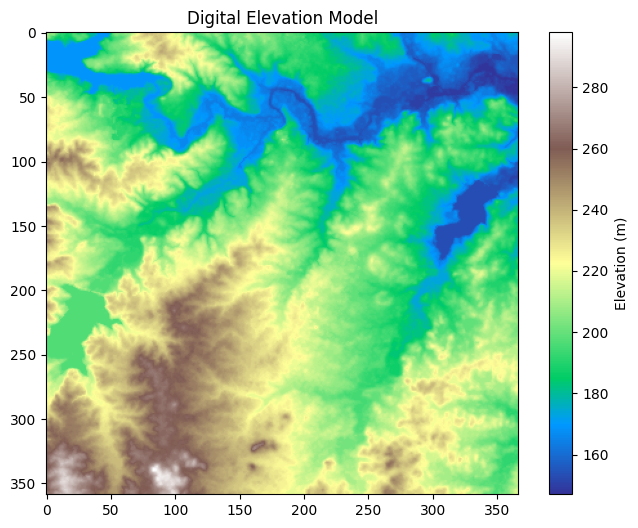

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dem, cmap='terrain', zorder=1)
plt.colorbar(im, label='Elevation (m)')
plt.title('Digital Elevation Model')
plt.show()

In [4]:
dem_filled = grid.fill_pits(dem)
dem_flooded = grid.fill_depressions(dem_filled)
dem_conditioned = grid.resolve_flats(dem_flooded)

dirmap = (64, 128, 1, 2, 4, 8, 16, 32)
# Pour point cooridnates (longitude, latitude)
x, y = -97.294167, 32.73750

# Generate Flow Direction
fdir = grid.flowdir(dem_conditioned, dirmap=dirmap)


In [5]:
catch = grid.catchment(x=x, y=y, fdir=fdir, dirmap=dirmap, 
                       xytype='label', algorithm='iterative')

# Clip the Grid to the Catchment
grid.clip_to(catch)

In [6]:
# 1. Compute accumulation to find a valid pour point inside the actual data
acc = grid.accumulation(fdir=fdir, dirmap=dirmap)

# 2. Find the point of maximum accumulation
y_idx, x_idx = np.unravel_index(np.argmax(acc), acc.shape)
x_pour, y_pour = grid.affine * (x_idx, y_idx) 

# 3. Delineate
catch = grid.catchment(x=x_pour, y=y_pour, fdir=fdir, dirmap=dirmap, 
                       recursionlimit=15000, xytype='label')

# 4. Clip the grid
grid.clip_to(catch)

# 5. FIX FOR INDEXERROR: Re-read the data objects for the clipped area
# This ensures metadata is perfectly 'congruent' with the new grid size
dem_view = grid.read_raster(FILE).astype(np.float64)
fdir_view = grid.view(fdir) # Using view on the Raster object
acc_view = grid.view(acc)
catch_view = grid.view(catch)

print(f"Corrected dem_view shape: {dem_view.shape}")

Corrected dem_view shape: (359, 367)


In [13]:
# Create river mask
river_mask = (acc_view > 100) & (catch_view > 0)

# Extract network
river_net = grid.extract_river_network(fdir=fdir_view, mask=river_mask)

# Rebuild the yx dictionary for the old plot loops
branches = []
yx = {}

for feature in river_net['features']:
    b_id = feature['id']
    coords = np.array(feature['geometry']['coordinates'])
    # Store as [y, x] to match your plot(line[:, 1], line[:, 0]) logic
    yx[b_id] = np.column_stack([coords[:, 1], coords[:, 0]])
    branches.append(b_id)

In [14]:
print(f"Max accumulation in view: {acc_view.max()}")
print(f"Number of river branches found: {len(branches)}")
if len(branches) > 0:
    print(f"Sample coordinate from first branch: {yx[branches[0]][0]}")

Max accumulation in view: 11408.0
Number of river branches found: 59
Sample coordinate from first branch: [ 32.723333 -97.29    ]


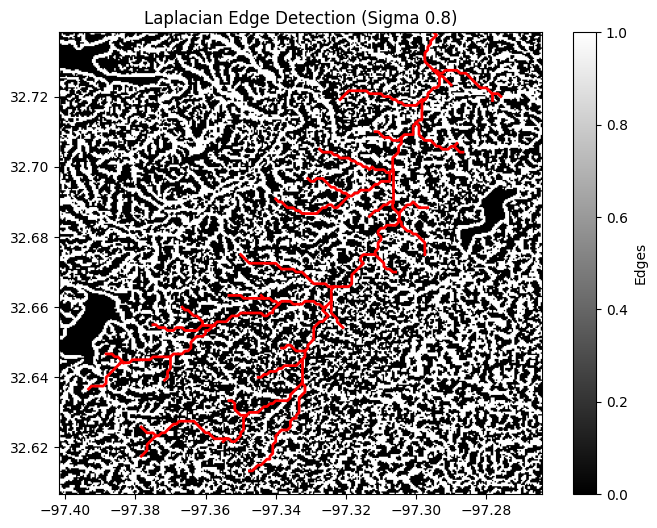

In [19]:
fig, ax = plt.subplots(figsize=(8,6))

# Apply Laplacian filter (binary B&W look)
plt.imshow((ndimage.gaussian_laplace(dem_view, 0.8) > 0).astype(int), 
           zorder=1, extent=grid.extent, cmap='gray')

plt.colorbar(label='Edges')

# Plot the river lines in red
for branch in branches:
    line = yx[branch]
    # line[:, 1] is Longitude, line[:, 0] is Latitude
    plt.plot(line[:, 1], line[:, 0], c='r', linewidth=2)

plt.title('Laplacian Edge Detection (Sigma 0.8)')
plt.show()

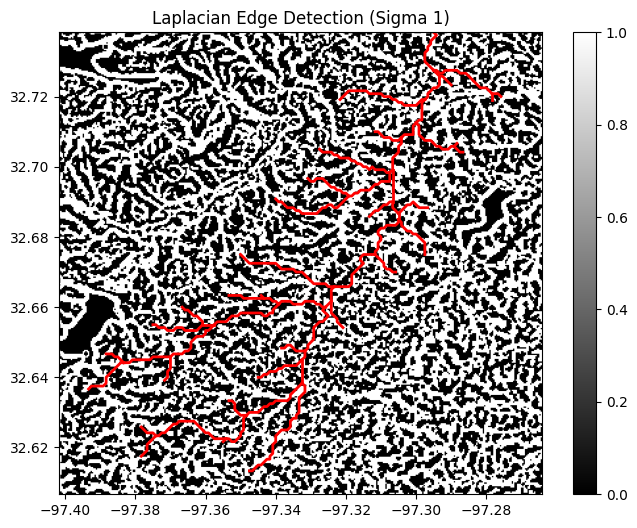

In [18]:
fig, ax = plt.subplots(figsize=(8,6))

plt.imshow((ndimage.gaussian_laplace(dem_view, 1) > 0).astype(int), 
           zorder=1, extent=grid.extent, cmap='gray')

plt.colorbar()

for branch in branches:
    line = yx[branch]
    plt.plot(line[:, 1], line[:, 0], c='r', linewidth=2)

plt.title('Laplacian Edge Detection (Sigma 1)')
plt.show()

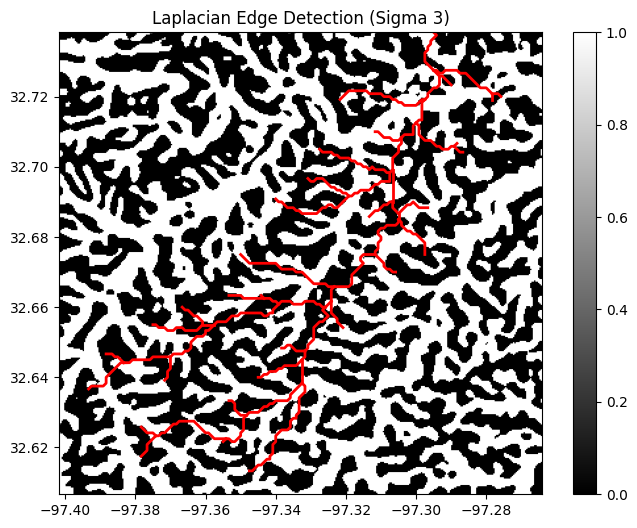

In [21]:
fig, ax = plt.subplots(figsize=(8,6))

plt.imshow((ndimage.gaussian_laplace(dem_view, 3) > 0).astype(int), 
           zorder=1, extent=grid.extent, cmap='gray')

plt.colorbar()

for branch in branches:
    line = yx[branch]
    plt.plot(line[:, 1], line[:, 0], c='r', linewidth=2)

plt.title('Laplacian Edge Detection (Sigma 3)')
plt.show()

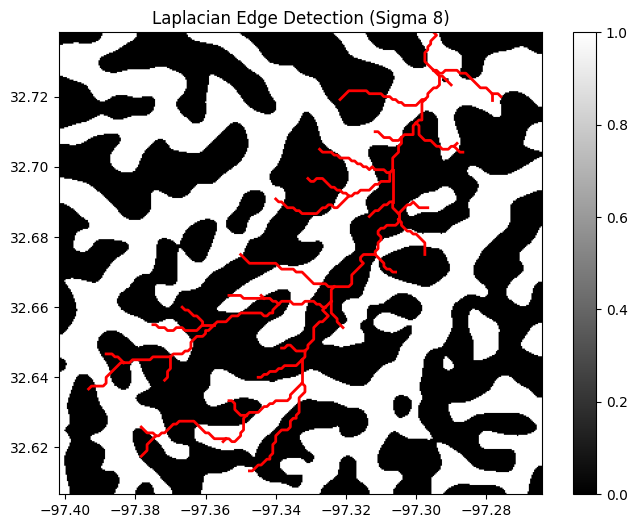

In [22]:
fig, ax = plt.subplots(figsize=(8,6))

plt.imshow((ndimage.gaussian_laplace(dem_view, 8) > 0).astype(int), 
           zorder=1, extent=grid.extent, cmap='gray')

plt.colorbar()

for branch in branches:
    line = yx[branch]
    plt.plot(line[:, 1], line[:, 0], c='r', linewidth=2)

plt.title('Laplacian Edge Detection (Sigma 8)')
plt.show()

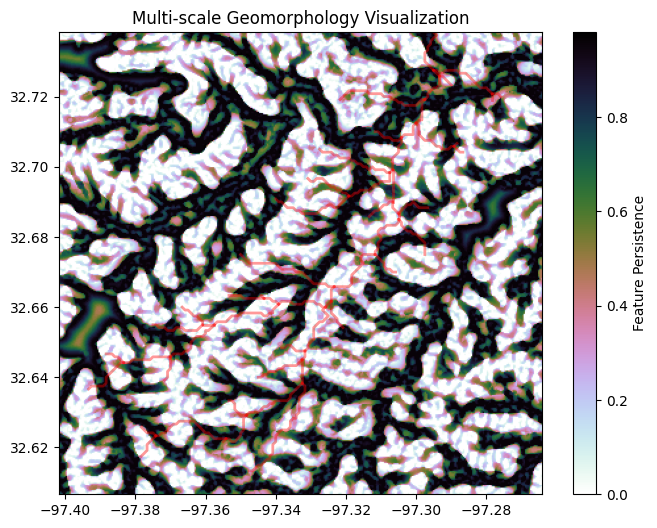

In [24]:
r = np.linspace(0.5, 8, 50)
z = np.zeros_like(dem_view)

for ri in r:
    # Build probability map of features
    z += ((ndimage.gaussian_laplace(dem_view, ri) > 0).astype(int) / len(r))

fig, ax = plt.subplots(figsize=(8,6))
plt.imshow(z, zorder=1, cmap='cubehelix_r', extent=grid.extent)
plt.colorbar(label='Feature Persistence')

for branch in branches:
    line = yx[branch]
    plt.plot(line[:, 1], line[:, 0], c='red', alpha=0.4, linewidth=2)

plt.title('Multi-scale Geomorphology Visualization')
plt.show()